# Cell-Type Importance & Permutation Test (HA model)

This notebook computes per-**cell-type importance scores** for the trained HA model
and assesses their statistical significance via a **label-permutation test**, following
the methodology of *Do et al. (hier-mil)*.

**Pipeline**
1. **Logit decomposition** (`HAModel.decompose_logits`) — splits each patient logit into
   additive per-cell-type contributions: `contrib[patient, ct, class] = w_ct * (X @ W_outᵀ)`.
2. **Observed importance** — replays the **20-seed × StratifiedShuffleSplit(test=6) × inner 3-fold CV** strategy from `ha_20seeds_3fold_cv.ipynb`; on each seed's outer-test (6 donors) calls `decompose_logits`, computes a per-seed cell-type importance score, then averages across the 20 seeds.
3. **Permutation null** — shuffles donor labels and re-runs the **identical** 20-seed × inner 3-fold pipeline, recomputing the (mean-across-seeds) importance vector. Repeat `N_PERM` times.
4. **p-values** — fraction of permuted importances ≥ observed, then **Benjamini–Hochberg
   FDR** correction.

> ⚠ Cost: permutations re-train models from scratch. Set `N_PERM` accordingly
> (e.g. 20–50 for a first pass, 100 for publication).


## Block 1 — Imports

In [3]:
import os
import random
import copy
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from statsmodels.stats.multitest import multipletests
import scanpy as sc
import matplotlib.pyplot as plt
from torch_geometric.utils import softmax
from torch_geometric.nn import global_add_pool, global_mean_pool

print(f"PyTorch: {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")


PyTorch: 2.8.0  |  CUDA: False
Device : cpu


## Block 2 — Reproducibility

In [4]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("Seed set ✓")


Seed set ✓


## Block 3 — Hyperparameters (matched to `ha_20seeds_3fold_cv.ipynb`)

In [6]:
# ── Data ─────────────────────────────────────────────────────
DATA_PATH = "../data_healthy_inflamed/kong_5000_healthy_inflamed_5000hvg.h5ad"
PATIENT_ID_KEY = "donor_id"
LABEL_KEY      = "Type"
CELL_TYPE_KEY  = "Celltype"
EMBEDDING_KEY  = "X_scGPT"
LABEL_MAP      = {"Heal": 0, "Infl": 1}
LABEL_NAMES    = {0: "Normal", 1: "Inflamed"}
NUM_CLASSES    = 2

# ── HA model ─────────────────────────────────────────────────
ATTN1, ATTN2   = False, True
N_HID          = 256
N_LAYERS_LIN   = 1
DROPOUT        = 0.3

# ── Training ─────────────────────────────────────────────────
LEARNING_RATE  = 1e-3
WEIGHT_DECAY   = 1e-4
MAX_EPOCHS     = 150
RANDOM_SEED    = 42

# ── Nested CV ────────────────────────────────────────────────
SEEDS          = list(range(20))   # 20 outer seeds (matches ha_20seeds_3fold_cv.ipynb)
TEST_SIZE      = 6                 # donors held out per seed via StratifiedShuffleSplit
N_INNER_FOLDS  = 3
PATIENCE       = 10
MIN_DELTA      = 1e-4

# ── Permutation test ─────────────────────────────────────────
N_PERM         = 100          # set 100 for publication; 20 for quick smoke-test
PERM_SEED_BASE = 1000        # label-shuffle seeds: PERM_SEED_BASE..+N_PERM-1
FDR_ALPHA      = 0.05

OUT_DIR        = "results"
os.makedirs(OUT_DIR, exist_ok=True)

print(f"N_PERM={N_PERM}  Seeds={len(SEEDS)}  TestSize={TEST_SIZE}  Inner={N_INNER_FOLDS}  MaxEpochs={MAX_EPOCHS}")


N_PERM=100  Seeds=20  TestSize=6  Inner=3  MaxEpochs=150


## Block 4 — Load Data

In [6]:
adata = sc.read_h5ad(DATA_PATH)
adata.obs["label"] = adata.obs[LABEL_KEY].map(LABEL_MAP).astype(int)

ALL_CT  = sorted(adata.obs[CELL_TYPE_KEY].unique().tolist())
N_CT    = len(ALL_CT)
CT_DICT = {ct: i for i, ct in enumerate(ALL_CT)}

embeddings = adata.obsm[EMBEDDING_KEY]
N_FEATURES = embeddings.shape[1]

df = pd.DataFrame(embeddings, index=adata.obs.index)
df["patient"]                = adata.obs[PATIENT_ID_KEY].values
df["cell_type_annotation"]   = adata.obs[CELL_TYPE_KEY].values
df["label"]                  = adata.obs["label"].values

print(f"Cells={adata.shape[0]}  Donors={adata.obs[PATIENT_ID_KEY].nunique()}  "
      f"CellTypes={N_CT}  EmbDim={N_FEATURES}")


Cells=105492  Donors=28  CellTypes=68  EmbDim=512


## Block 5 — HA Model (with `decompose_logits`)

In [7]:
class HAModel(nn.Module):
    """HA MIL model — same as ha_20seeds_3fold_cv.ipynb, plus decompose_logits."""
    def __init__(self, n_in, n_out=2, attn1=True, attn2=True,
                 dropout=0.0, n_layers_lin=1, n_hid=256):
        super().__init__()
        self.attn1, self.attn2 = attn1, attn2
        self.lin = nn.Sequential(*self._build_layers(n_layers_lin, n_in, n_hid, n_hid, dropout))
        curr_in = n_in if len(self.lin) == 0 else n_hid
        self.n_in1 = curr_in
        self.w_c  = nn.Sequential(nn.Linear(curr_in, 1), nn.Dropout(dropout))
        self.w_ct = nn.Sequential(nn.Linear(curr_in, 1), nn.Dropout(dropout))
        self.lin_out = nn.Linear(curr_in, n_out)

    def _build_layers(self, n_layers, n_in, n_hid, n_out, dropout):
        layers = []
        for i in range(n_layers):
            c_in  = n_in if i == 0 else n_hid
            c_out = n_out if i == n_layers - 1 else n_hid
            layers.extend([nn.Linear(c_in, c_out), nn.ReLU(), nn.Dropout(dropout)])
        return layers

    def forward(self, X, batch, ct_size, n_ct):
        X = self.lin(X)
        if self.attn1:
            w_c = softmax(self.w_c(X).squeeze(-1), batch)
            X = global_add_pool(X * w_c.unsqueeze(-1), batch, size=ct_size)
        else:
            X = global_mean_pool(X, batch, size=ct_size)
        X = X.reshape(-1, n_ct, self.n_in1)
        if self.attn2:
            w_ct = torch.softmax(self.w_ct(X), dim=1)
            X = torch.sum(X * w_ct, dim=1)
        else:
            X = torch.mean(X, dim=1)
        return self.lin_out(X)

    def decompose_logits(self, X, batch, ct_size, n_ct):
        """
        Returns per-cell-type, per-class contributions to the patient logit.
        contrib[i, c, k] = w_ct[i, c] * (X_pooled[i, c] @ W_outᵀ)[k]
        Note: the lin_out bias is NOT attributed to any cell type
              (it's a constant added once at the patient level), matching hier-mil.
        """
        X = self.lin(X)
        w_c = softmax(self.w_c(X).squeeze(-1), batch)
        X = global_add_pool(X * w_c.unsqueeze(-1), batch, size=ct_size)
        X = X.reshape(-1, n_ct, self.n_in1)
        w_ct = torch.softmax(self.w_ct(X), dim=1)        # (n_pat, n_ct, 1)
        X = X @ self.lin_out.weight.T                    # (n_pat, n_ct, n_out)
        contrib = w_ct * X                               # (n_pat, n_ct, n_out)
        return contrib, w_ct.squeeze(-1)

print("HAModel defined ✓")


HAModel defined ✓


## Block 6 — Tensor builders & training utilities (same as main notebook)

In [8]:
def get_data(df, all_ct, samples, n_features):
    ct_dict = {ct: i for i, ct in enumerate(all_ct)}
    n_ct = len(all_ct)
    Xs, batches = [], []
    for idx, patient in enumerate(samples["patient"].tolist()):
        sample_df = df[df["patient"] == patient]
        x = sample_df.iloc[:, :n_features].to_numpy()
        b = [idx * n_ct + ct_dict[ct] for ct in sample_df["cell_type_annotation"].tolist()]
        Xs.append(x); batches.append(b)
    X = torch.tensor(np.concatenate(Xs), dtype=torch.float)
    B = torch.tensor(np.concatenate(batches), dtype=torch.long)
    y = torch.tensor(samples["label"].tolist(), dtype=torch.long)
    return X, y, B


def compute_class_weights(labels):
    n_total = len(labels)
    weights = []
    for c in range(NUM_CLASSES):
        n_c = (labels == c).sum()
        weights.append(n_total / (NUM_CLASSES * n_c) if n_c > 0 else 1.0)
    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


def build_fold_tensors(samples_subset, df_for_tensor):
    X, y, b = get_data(df_for_tensor, ALL_CT, samples_subset, N_FEATURES)
    X, y, b = X.to(DEVICE), y.to(DEVICE), b.to(DEVICE)
    ct_size = N_CT * len(samples_subset)
    return X, y, b, ct_size


def make_model_optim_sched(train_labels_fold, max_epochs):
    model = HAModel(
        n_in=N_FEATURES, n_out=NUM_CLASSES,
        attn1=ATTN1, attn2=ATTN2,
        dropout=DROPOUT, n_layers_lin=N_LAYERS_LIN, n_hid=N_HID,
    ).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
    criterion = nn.CrossEntropyLoss(weight=compute_class_weights(train_labels_fold))
    return model, optimizer, scheduler, criterion


def train_one_epoch(model, X, y, b, ct_size, n_ct, crit, opt):
    model.train()
    opt.zero_grad()
    logits = model(X, b, ct_size, n_ct)
    loss = crit(logits, y)
    loss.backward()
    opt.step()
    return loss.item()


@torch.no_grad()
def evaluate(model, X, y, b, ct_size, n_ct, crit):
    model.eval()
    logits = model(X, b, ct_size, n_ct)
    return crit(logits, y).item()

print("Utilities defined ✓")


Utilities defined ✓


## Block 7 — Per-permutation 20-seed CV importance extractor

This replicates the **exact** training pipeline from `ha_20seeds_3fold_cv.ipynb`:

* Outer loop over 20 seeds; each seed uses `StratifiedShuffleSplit(test_size=6, random_state=seed_id)`.
* For each seed: inner 3-fold CV (`StratifiedKFold(random_state=seed_id)`) → early-stopping on **mean inner val loss** to pick `best_epoch`.
* Refit on full outer-train for `best_epoch` epochs (re-seeded via `set_seed(seed_id)`).
* On the outer-test (6 donors), call `decompose_logits` to obtain per-cell-type signed contributions and compute a per-seed importance score.

Returns the mean importance vector across the 20 seeds (and the full per-seed matrix for diagnostics).

In [9]:
def run_20seed_cv_and_score(df_in, label_seed=None, verbose=False):
    """
    Runs the 20-seed × inner 3-fold pipeline from `ha_20seeds_3fold_cv.ipynb`,
    decomposes logits on each seed's outer-test, and returns the importance score.

    df_in : DataFrame identical in structure to the global df. If label_seed is provided,
            donor labels are shuffled (the same shuffle applied to every row of a donor).
    Returns:
        mean_score      : (N_CT,)            mean importance across the 20 seeds
        per_seed_scores : (len(SEEDS), N_CT) per-seed importance for diagnostics
    """
    samples = df_in[["patient", "label"]].drop_duplicates().reset_index(drop=True)

    # Optional donor-level label shuffle for the permutation null
    if label_seed is not None:
        rng = np.random.RandomState(label_seed)
        shuffled = rng.permutation(samples["label"].values)
        samples = samples.copy()
        samples["label"] = shuffled
        lbl_map = dict(zip(samples["patient"], samples["label"]))
        df_run = df_in.copy()
        df_run["label"] = df_run["patient"].map(lbl_map).astype(int)
    else:
        df_run = df_in

    all_labels = samples["label"].values
    per_seed_scores = np.zeros((len(SEEDS), N_CT), dtype=np.float32)

    for s_idx, seed_id in enumerate(SEEDS):
        # ── Outer split: StratifiedShuffleSplit(test_size=6, random_state=seed_id) ──
        sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=seed_id)
        otr_idx, ote_idx = next(sss.split(np.arange(len(samples)), all_labels))
        outer_train = samples.iloc[otr_idx].reset_index(drop=True)
        outer_test  = samples.iloc[ote_idx].reset_index(drop=True)
        otr_labels  = outer_train["label"].values

        # ── Inner 3-fold CV → best_epoch via mean val loss + early stopping ──
        inner_skf = StratifiedKFold(
            n_splits=N_INNER_FOLDS, shuffle=True, random_state=seed_id
        )
        inner_models, inner_data = [], []
        set_seed(seed_id)
        for inner_tr_idx, inner_val_idx in inner_skf.split(
            np.arange(len(outer_train)), otr_labels
        ):
            inner_tr  = outer_train.iloc[inner_tr_idx].reset_index(drop=True)
            inner_val = outer_train.iloc[inner_val_idx].reset_index(drop=True)
            X_tr, y_tr, b_tr, sz_tr = build_fold_tensors(inner_tr,  df_run)
            X_va, y_va, b_va, sz_va = build_fold_tensors(inner_val, df_run)
            m, o, sch, c = make_model_optim_sched(inner_tr["label"].values, MAX_EPOCHS)
            inner_models.append((m, o, sch, c))
            inner_data.append((X_tr, y_tr, b_tr, sz_tr, X_va, y_va, b_va, sz_va))

        best_loss, best_epoch, patience = float("inf"), 1, 0
        for epoch in range(1, MAX_EPOCHS + 1):
            vls = []
            for (m, o, sch, c), (Xt, yt, bt, szt, Xv, yv, bv, szv) in zip(inner_models, inner_data):
                train_one_epoch(m, Xt, yt, bt, szt, N_CT, c, o)
                vls.append(evaluate(m, Xv, yv, bv, szv, N_CT, c))
                sch.step()
            mvl = float(np.mean(vls))
            if mvl < best_loss - MIN_DELTA:
                best_loss, best_epoch, patience = mvl, epoch, 0
            else:
                patience += 1
                if patience >= PATIENCE:
                    break

        # ── Refit on full outer-train for best_epoch ──
        X_otr, y_otr, b_otr, sz_otr = build_fold_tensors(outer_train, df_run)
        X_ote, y_ote, b_ote, sz_ote = build_fold_tensors(outer_test,  df_run)
        set_seed(seed_id)
        final_model, final_opt, final_sched, final_crit = make_model_optim_sched(
            otr_labels, max_epochs=best_epoch
        )
        for _ in range(best_epoch):
            train_one_epoch(final_model, X_otr, y_otr, b_otr, sz_otr, N_CT, final_crit, final_opt)
            final_sched.step()

        # ── Decompose on outer-test → per-seed importance score ──
        final_model.eval()
        with torch.no_grad():
            contrib, _ = final_model.decompose_logits(X_ote, b_ote, sz_ote, N_CT)
        contrib_np = contrib.cpu().numpy()  # (n_test, N_CT, NUM_CLASSES)
        per_seed_scores[s_idx] = importance_from_contribs(contrib_np, outer_test["label"].values)

        if verbose:
            print(f"    seed {seed_id}: best_epoch={best_epoch}  (mean val loss={best_loss:.4f})")

    return per_seed_scores.mean(axis=0), per_seed_scores


def importance_from_contribs(contribs, truths):
    """
    Binary-classification importance per cell type:
      diff[i, c]   = contrib[i, c, 1] - contrib[i, c, 0]
      score[c]    = mean_{i: y=1}(diff[i, c]) - mean_{i: y=0}(diff[i, c])
    Positive scores ⇒ that cell type pushes the model toward the Inflamed class
    more for Inflamed donors than for Normal donors.

    If a class is missing from `truths` (can happen on a small outer-test of 6 donors
    under permutation), that class's mean contribution defaults to 0 to avoid NaN.
    """
    diff = contribs[..., 1] - contribs[..., 0]            # (n_pat, N_CT)
    pos_mask = (truths == 1)
    neg_mask = (truths == 0)
    pos_mean = diff[pos_mask].mean(0) if pos_mask.any() else np.zeros(diff.shape[1], dtype=diff.dtype)
    neg_mean = diff[neg_mask].mean(0) if neg_mask.any() else np.zeros(diff.shape[1], dtype=diff.dtype)
    return pos_mean - neg_mean                            # (N_CT,)

print("20-seed CV decomposition functions defined ✓")


20-seed CV decomposition functions defined ✓


## Block 8 — Observed importance (from saved 20-seed checkpoints)

Loads the per-seed checkpoints `best_ha_model_seed{00..19}.pt` produced by
`ha_20seeds_3fold_cv.ipynb` (saved under `checkpoints_20seeds/`), replays the **same**
20-seed outer split, and applies `decompose_logits` to each seed's outer-test (6 donors).
Per-seed importance scores are averaged across the 20 seeds. No retraining required —
these checkpoints were trained with the identical 20-seed pipeline used for the permutation null below.


In [8]:
CKPT_DIR = "checkpoints_20seeds"   # folder containing best_ha_model_seed{00..19}.pt

# Sanity: all checkpoints present
missing = [s for s in SEEDS
           if not os.path.exists(os.path.join(CKPT_DIR, f"best_ha_model_seed{s:02d}.pt"))]
assert not missing, f"Missing checkpoints for seeds: {missing}"

samples = df[["patient", "label"]].drop_duplicates().reset_index(drop=True)
all_labels = samples["label"].values

per_seed_scores_obs = np.zeros((len(SEEDS), N_CT), dtype=np.float32)

print("══ Observed run (saved 20-seed checkpoints) ══")
for s_idx, seed_id in enumerate(SEEDS):
    sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=seed_id)
    _, ote_idx = next(sss.split(np.arange(len(samples)), all_labels))
    test_samples = samples.iloc[ote_idx].reset_index(drop=True)
    X_te, y_te, b_te, sz_te = build_fold_tensors(test_samples, df)

    model = HAModel(
        n_in=N_FEATURES, n_out=NUM_CLASSES,
        attn1=ATTN1, attn2=ATTN2,
        dropout=DROPOUT, n_layers_lin=N_LAYERS_LIN, n_hid=N_HID,
    ).to(DEVICE)
    model.load_state_dict(torch.load(
        os.path.join(CKPT_DIR, f"best_ha_model_seed{seed_id:02d}.pt"),
        map_location=DEVICE, weights_only=True,
    ))
    model.eval()

    with torch.no_grad():
        contrib, _ = model.decompose_logits(X_te, b_te, sz_te, N_CT)

    per_seed_scores_obs[s_idx] = importance_from_contribs(
        contrib.cpu().numpy(), test_samples["label"].values
    )
    print(f"  seed {seed_id:>2}: decomposed {len(ote_idx)} test donors")

obs_score = per_seed_scores_obs.mean(axis=0)
np.save(os.path.join(OUT_DIR, "per_seed_scores_observed.npy"), per_seed_scores_obs)

obs_df = pd.DataFrame({"cell_type": ALL_CT, "importance_score": obs_score}) \
            .sort_values("importance_score", ascending=False).reset_index(drop=True)
obs_df.to_csv(os.path.join(OUT_DIR, "ct_importance_observed.csv"), index=False)
obs_df.head(20)


══ Observed run (saved 20-seed checkpoints) ══
  seed  0: decomposed 6 test donors


  seed  1: decomposed 6 test donors
  seed  2: decomposed 6 test donors


  seed  3: decomposed 6 test donors
  seed  4: decomposed 6 test donors


  seed  5: decomposed 6 test donors
  seed  6: decomposed 6 test donors


  seed  7: decomposed 6 test donors
  seed  8: decomposed 6 test donors


...

  seed 13: decomposed 6 test donors
  seed 14: decomposed 6 test donors


  seed 15: decomposed 6 test donors
  seed 16: decomposed 6 test donors


  seed 17: decomposed 6 test donors
  seed 18: decomposed 6 test donors


  seed 19: decomposed 6 test donors


,cell_type,importance_score
0,Stem cells OLFM4 LGR5,0.121623
1,Enterocytes CA1 CA2 CA4-,0.118587
2,Epithelial Cycling cells,0.112225
3,Enterocytes TMIGD1 MEP1A,0.111081
4,Stem cells OLFM4 PCNA,0.110308
5,Enterocytes BEST4,0.099415
6,Stem cells OLFM4,0.096269
7,Goblet cells MUC2 TFF1,0.074320
8,Goblet cells MUC2 TFF1-,0.073127
9,Paneth cells,0.043366


## Block 9 — Permutation null distribution

Re-runs the **same** 20-seed × inner 3-fold CV training pipeline `N_PERM` times with shuffled donor labels.

In [9]:
import sys

perm_scores = np.zeros((N_PERM, N_CT), dtype=np.float32)
t0 = time.time()
print(f"Starting permutation null: N_PERM={N_PERM}, SEEDS={len(SEEDS)} per perm, "
      f"inner folds={N_INNER_FOLDS}", flush=True)

for p in range(N_PERM):
    seed = PERM_SEED_BASE + p
    t_perm = time.time()
    print(f"\n▶ perm {p+1:>3}/{N_PERM}  (label_seed={seed}) — starting "
          f"{time.strftime('%H:%M:%S')}", flush=True)

    score_p, _ = run_20seed_cv_and_score(df, label_seed=seed, verbose=True)
    perm_scores[p] = score_p

    perm_time = time.time() - t_perm
    elapsed   = time.time() - t0
    eta       = elapsed / (p + 1) * (N_PERM - p - 1)
    print(f"✓ perm {p+1:>3}/{N_PERM}  seed={seed}  "
          f"max|score|={np.max(np.abs(perm_scores[p])):.3f}  "
          f"perm_time={perm_time/60:.1f}m  "
          f"elapsed={elapsed/60:.1f}m  ETA={eta/60:.1f}m", flush=True)

total_time = time.time() - t0
h, rem = divmod(total_time, 3600)
m, s = divmod(rem, 60)
print(f"\n⏱  Total permutation runtime: {int(h):02d}h {int(m):02d}m {s:05.2f}s "
      f"({total_time:.1f}s, {total_time/60:.2f}m)")
print(f"   Avg per permutation: {total_time/N_PERM:.1f}s ({total_time/N_PERM/60:.2f}m)")

np.save(os.path.join(OUT_DIR, "perm_scores.npy"), perm_scores)
print(f"Permutation null saved: shape={perm_scores.shape}")


Starting permutation null: N_PERM=100, SEEDS=20 per perm, inner folds=3



▶ perm   1/100  (label_seed=1000) — starting 14:07:25


    seed 0: best_epoch=1  (mean val loss=0.6924)


    seed 1: best_epoch=32  (mean val loss=0.6800)


    seed 2: best_epoch=87  (mean val loss=0.5620)


...

    seed 16: best_epoch=14  (mean val loss=0.6904)


    seed 17: best_epoch=2  (mean val loss=0.6942)


    seed 18: best_epoch=1  (mean val loss=0.6919)


    seed 19: best_epoch=1  (mean val loss=0.6936)
✓ perm 100/100  seed=1099  max|score|=0.000  perm_time=6.6m  elapsed=1850.2m  ETA=0.0m



⏱  Total permutation runtime: 30h 50m 10.17s (111010.2s, 1850.17m)
   Avg per permutation: 1110.1s (18.50m)
Permutation null saved: shape=(100, 68)


## Block 10 — p-values + BH-FDR correction


In [10]:
# Load perm_scores / obs_score from disk if not in memory (e.g. after kernel restart)
if "perm_scores" not in dir():
    perm_path = os.path.join(OUT_DIR, "perm_scores.npy")
    assert os.path.exists(perm_path), f"perm_scores.npy not found at {perm_path}. Run Block 9 first."
    perm_scores = np.load(perm_path)
    print(f"Loaded perm_scores from disk: shape={perm_scores.shape}")

if "obs_score" not in dir():
    obs_path = os.path.join(OUT_DIR, "per_seed_scores_observed.npy")
    assert os.path.exists(obs_path), f"per_seed_scores_observed.npy not found at {obs_path}. Run Block 8 first."
    obs_score = np.load(obs_path).mean(axis=0)
    print(f"Loaded obs_score from disk: shape={obs_score.shape}")

# One-sided: fraction of permuted importances that meet or exceed the observed
p_raw = (perm_scores >= obs_score[None, :]).sum(0) / N_PERM

# BH-FDR correction across cell types
_, p_adj, _, _ = multipletests(p_raw, alpha=FDR_ALPHA, method="fdr_bh")

results = pd.DataFrame({
    "cell_type":         ALL_CT,
    "importance_score":  obs_score,
    "p_value":           p_raw,
    "p_adj_bh":          p_adj,
    "significant":       p_adj < FDR_ALPHA,
}).sort_values("importance_score", ascending=False).reset_index(drop=True)

results.to_csv(os.path.join(OUT_DIR, "ct_importance_with_pvals.csv"), index=False)
print(f"Significant cell types (BH-FDR < {FDR_ALPHA}): "
      f"{int(results['significant'].sum())}/{len(results)}")
results


Significant cell types (BH-FDR < 0.05): 63/68


,cell_type,importance_score,p_value,p_adj_bh,significant
0,Stem cells OLFM4 LGR5,0.121623,0.00,0.000000,True
1,Enterocytes CA1 CA2 CA4-,0.118587,0.00,0.000000,True
2,Epithelial Cycling cells,0.112225,0.00,0.000000,True
3,Enterocytes TMIGD1 MEP1A,0.111081,0.00,0.000000,True
4,Stem cells OLFM4 PCNA,0.110308,0.00,0.000000,True
...,...,...,...,...,...
63,B cells AICDA LRMP,0.000946,0.10,0.106250,False
64,Monocytes HBB,0.000571,0.15,0.156923,False
65,Macrophages CXCL9 CXCL10,-0.000222,0.66,0.680000,False
66,Enterocytes TMIGD1 MEP1A GSTA1,-0.003791,0.99,1.000000,False


In [11]:
# Per cell type: how many null-distribution SDs the observed score sits above the null mean
null_mean = perm_scores.mean(axis=0)                    # in ALL_CT order
null_std  = perm_scores.std(axis=0, ddof=1)             # in ALL_CT order
null_std_safe = np.where(null_std == 0, np.nan, null_std)
z_score = (obs_score - null_mean) / null_std_safe       # in ALL_CT order

# `results` was sorted by importance_score in Block 10, so we must align
# the ALL_CT-ordered arrays to its current cell_type order before assigning.
ct_to_idx = {ct: i for i, ct in enumerate(ALL_CT)}
order = results["cell_type"].map(ct_to_idx).to_numpy()

results["null_mean"] = null_mean[order]
results["null_std"]  = null_std[order]
results["z_score"]   = z_score[order]

# Overwrite the original CSV (now includes z-score column)
results.to_csv(os.path.join(OUT_DIR, "ct_importance_with_pvals.csv"), index=False)

# Separate CSV sorted by z-score (descending)
results_by_z = results.sort_values("z_score", ascending=False).reset_index(drop=True)
results_by_z.to_csv(os.path.join(OUT_DIR, "ct_importance_with_zscores.csv"), index=False)

print(f"z-score range: [{z_score.min():.2f}, {z_score.max():.2f}]")
print(f"Cell types with z >= 3 : {(z_score >= 3).sum()}/{len(z_score)}")
print(f"Cell types with z >= 5 : {(z_score >= 5).sum()}/{len(z_score)}")
print(f"Saved: {os.path.join(OUT_DIR, 'ct_importance_with_pvals.csv')} (with z_score column)")
print(f"Saved: {os.path.join(OUT_DIR, 'ct_importance_with_zscores.csv')} (sorted by z-score)")
results_by_z.head(15)


z-score range: [-8.05, 54.38]
Cell types with z >= 3 : 60/68
Cell types with z >= 5 : 56/68
Saved: results/ct_importance_with_pvals.csv (with z_score column)
Saved: results/ct_importance_with_zscores.csv (sorted by z-score)


,cell_type,importance_score,p_value,p_adj_bh,significant,null_mean,null_std,z_score
0,Enterocytes CA1 CA2 CA4-,0.118587,0.0,0.0,True,-0.000125,0.002183,54.375584
1,Goblet cells MUC2 TFF1,0.074320,0.0,0.0,True,-0.000119,0.001838,40.503475
2,Stem cells OLFM4 PCNA,0.110308,0.0,0.0,True,0.000015,0.003124,35.300358
3,Epithelial Cycling cells,0.112225,0.0,0.0,True,0.000005,0.003226,34.789238
4,Enterocytes BEST4,0.099415,0.0,0.0,True,-0.000014,0.002927,33.966927
5,Goblet cells MUC2 TFF1-,0.073127,0.0,0.0,True,-0.000015,0.002198,33.277107
6,Enterocytes TMIGD1 MEP1A,0.111081,0.0,0.0,True,-0.000296,0.003353,33.216003
7,Stem cells OLFM4 LGR5,0.121623,0.0,0.0,True,-0.000018,0.003680,33.057178
8,Stem cells OLFM4,0.096269,0.0,0.0,True,-0.000049,0.002990,32.210091
9,Paneth cells,0.043366,0.0,0.0,True,0.000007,0.001365,31.758606


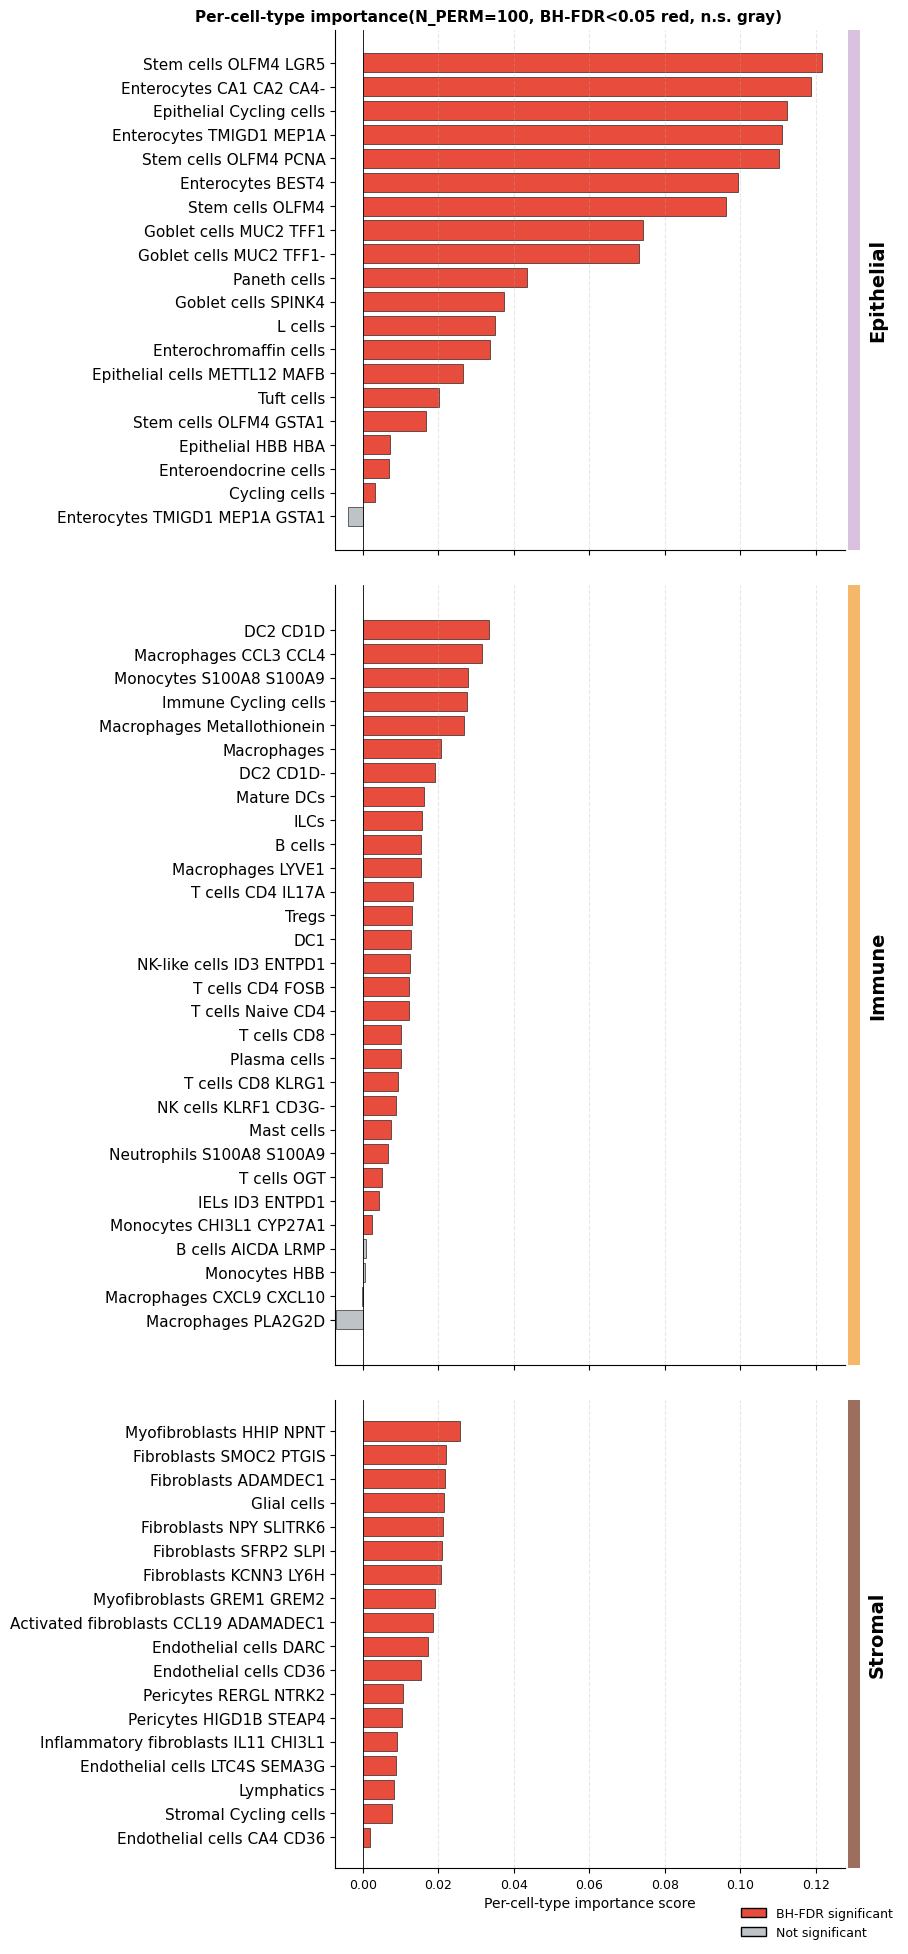

Saved → results/ct_importance_kong_style.png
Saved → results/ct_importance_kong_style.pdf


In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ── Load importance scores ────────────────────────────────────────────────
imp = pd.read_csv(os.path.join(OUT_DIR, "ct_importance_with_zscores.csv"))

# ── Kong-style compartment assignment ─────────────────────────────────────
# Mirrors Figure 3A grouping: Epithelial / Immune / Stromal.
EPITHELIAL = {
    "Enterocytes BEST4", "Enterocytes TMIGD1 MEP1A", "Enterocytes TMIGD1 MEP1A GSTA1",
    "Enterocytes CA1 CA2 CA4-",
    "Stem cells OLFM4", "Stem cells OLFM4 GSTA1", "Stem cells OLFM4 LGR5", "Stem cells OLFM4 PCNA",
    "Goblet cells MUC2 TFF1", "Goblet cells MUC2 TFF1-", "Goblet cells SPINK4",
    "Paneth cells", "Tuft cells",
    "Enteroendocrine cells", "Enterochromaffin cells", "L cells",
    "Epithelial Cycling cells", "Cycling cells",
    "Epithelial HBB HBA", "Epithelial cells METTL12 MAFB",
}
IMMUNE = {
    "B cells", "B cells AICDA LRMP", "Plasma cells",
    "T cells CD4 FOSB", "T cells CD4 IL17A", "T cells CD8", "T cells CD8 KLRG1",
    "T cells Naive CD4", "T cells OGT", "Tregs",
    "NK cells KLRF1 CD3G-", "NK-like cells ID3 ENTPD1",
    "ILCs", "IELs ID3 ENTPD1",
    "DC1", "DC2 CD1D", "DC2 CD1D-", "Mature DCs",
    "Macrophages", "Macrophages CCL3 CCL4", "Macrophages CXCL9 CXCL10",
    "Macrophages LYVE1", "Macrophages Metallothionein", "Macrophages PLA2G2D",
    "Monocytes CHI3L1 CYP27A1", "Monocytes HBB", "Monocytes S100A8 S100A9",
    "Mast cells", "Neutrophils S100A8 S100A9", "Immune Cycling cells",
}
STROMAL = {
    "Fibroblasts ADAMDEC1", "Fibroblasts KCNN3 LY6H", "Fibroblasts NPY SLITRK6",
    "Fibroblasts SFRP2 SLPI", "Fibroblasts SMOC2 PTGIS",
    "Activated fibroblasts CCL19 ADAMADEC1", "Inflammatory fibroblasts IL11 CHI3L1",
    "Myofibroblasts GREM1 GREM2", "Myofibroblasts HHIP NPNT",
    "Endothelial cells CA4 CD36", "Endothelial cells CD36",
    "Endothelial cells DARC", "Endothelial cells LTC4S SEMA3G",
    "Pericytes HIGD1B STEAP4", "Pericytes RERGL NTRK2",
    "Glial cells", "Lymphatics", "Stromal Cycling cells",
}

def _assign_compartment(ct):
    if ct in EPITHELIAL: return "Epithelial"
    if ct in IMMUNE:     return "Immune"
    if ct in STROMAL:    return "Stromal"
    return "Other"

imp["compartment"] = imp["cell_type"].map(_assign_compartment)
unmapped = imp.loc[imp["compartment"] == "Other", "cell_type"].tolist()
if unmapped:
    print("⚠ Unmapped cell types (re-classify if needed):", unmapped)

# ── Plot ──────────────────────────────────────────────────────────────────
COMPARTMENT_ORDER  = ["Epithelial", "Immune", "Stromal"]
COMPARTMENT_COLORS = {"Epithelial": "#D9C2E0", "Immune": "#F5B86A", "Stromal": "#9B6E5E"}
SIG_COLOR, NOT_SIG_COLOR = "#e74c3c", "#bdc3c7"

panels = [(c, imp[imp["compartment"] == c].sort_values("importance_score", ascending=True))
          for c in COMPARTMENT_ORDER]
heights = [max(1, len(d)) for _, d in panels]

fig, axes = plt.subplots(
    nrows=3, ncols=1,
    figsize=(8.5, 0.28 * sum(heights) + 1.5),
    gridspec_kw={"height_ratios": heights, "hspace": 0.06},
    sharex=True,
)

xmax = max(imp["importance_score"].max() * 1.05, 1e-3)
xmin = min(imp["importance_score"].min() * 1.05, 0)

for ax, (compartment, sub) in zip(axes, panels):
    colors = [SIG_COLOR if s else NOT_SIG_COLOR for s in sub["significant"]]
    ax.barh(sub["cell_type"], sub["importance_score"],
            color=colors, edgecolor="black", linewidth=0.4)
    ax.axvline(0, color="black", linewidth=0.6)
    ax.set_xlim(xmin, xmax)
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=11)
    ax.tick_params(axis="x", labelsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    # Right-edge colored gutter as a compartment label
    band = Rectangle((1.005, 0), 0.025, 1,
                     transform=ax.transAxes, clip_on=False,
                     facecolor=COMPARTMENT_COLORS[compartment], edgecolor="none")
    ax.add_patch(band)
    ax.text(1.045, 0.5, compartment, transform=ax.transAxes,
            rotation=90, va="center", ha="left", fontsize=14, fontweight="bold")

axes[-1].set_xlabel("Per-cell-type importance score",
                    fontsize=10)
fig.suptitle(f"Per-cell-type importance"
             f"(N_PERM={N_PERM}, BH-FDR<{FDR_ALPHA} red, n.s. gray)",
             fontsize=11, fontweight="bold", y=0.965)

# Legend
from matplotlib.patches import Patch
fig.legend(handles=[Patch(facecolor=SIG_COLOR, edgecolor="black", label="BH-FDR significant"),
                    Patch(facecolor=NOT_SIG_COLOR, edgecolor="black", label="Not significant")],
           loc="lower right", bbox_to_anchor=(0.99, 0.02), frameon=False, fontsize=9)

plt.subplots_adjust(top=0.955, bottom=0.06, left=0.32, right=0.92, hspace=0.06)
out_png = os.path.join(OUT_DIR, "ct_importance_kong_style.png")
out_pdf = os.path.join(OUT_DIR, "ct_importance_kong_style.pdf")
fig.savefig(out_png, dpi=200, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()
print(f"Saved → {out_png}")
print(f"Saved → {out_pdf}")


## Block 11 — Visualisation

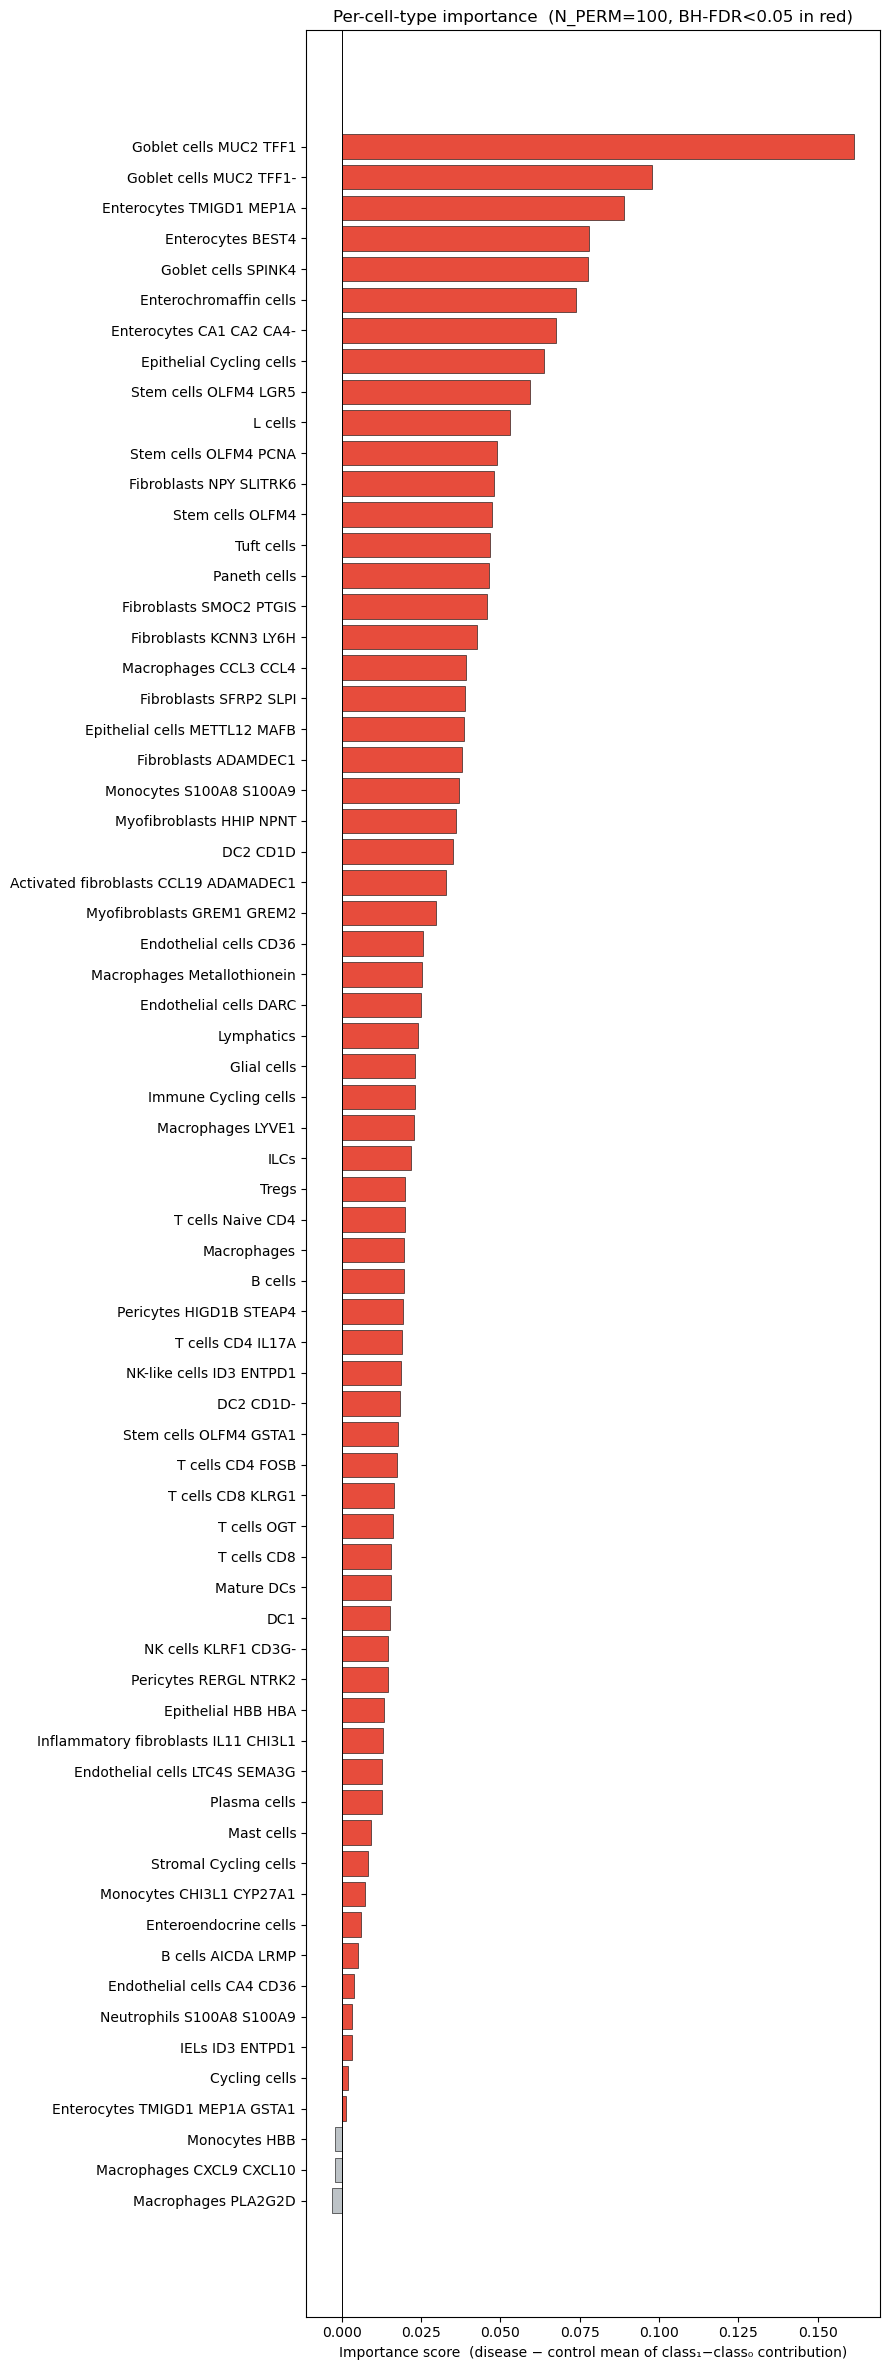

In [12]:
fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * N_CT)))
plot_df = results.sort_values("importance_score")
colors = ["#e74c3c" if s else "#bdc3c7" for s in plot_df["significant"]]
ax.barh(plot_df["cell_type"], plot_df["importance_score"], color=colors, edgecolor="black", linewidth=0.4)
ax.axvline(0, color="black", lw=0.7)
ax.set_xlabel("Importance score  (Inflamed − Normal mean of class₁−class₀ contribution)")
ax.set_title(f"Per-cell-type importance  (N_PERM={N_PERM}, BH-FDR<{FDR_ALPHA} in red)")
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "ct_importance_barplot.png"), dpi=150)
plt.show()


## Block 12 — Per-donor cell-count proportions for top-20 important cell types

For each importance ranking, take the **top-20 cell types in CSV row order**
and plot per-donor cell-count proportions, Inflamed vs Normal. Stats: Mann-Whitney U + BH-FDR.

Cell-count proportion:
```
prop_{donor, ct} = (# cells of type ct in donor) / (total cells in donor)
```


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

os.makedirs("results", exist_ok=True)

# df has columns: patient, cell_type_annotation, label  (label 0=Normal, 1=Inflamed)
INV_LABEL = {0: "Normal", 1: "Inflamed"}

_counts = (df.groupby(["patient", "cell_type_annotation"]).size()
             .unstack(fill_value=0))
for ct in ALL_CT:
    if ct not in _counts.columns:
        _counts[ct] = 0
_counts = _counts[ALL_CT]
_props  = _counts.div(_counts.sum(axis=1), axis=0)

_donor_label = df.drop_duplicates("patient").set_index("patient")["label"].map(INV_LABEL)

per_donor_prop = (_props.stack().rename("prop").reset_index()
                  .rename(columns={"cell_type_annotation": "cell_type"}))
per_donor_prop["disease"] = per_donor_prop["patient"].map(_donor_label)

print(f"per_donor_prop: {per_donor_prop.shape[0]} rows "
      f"({per_donor_prop['patient'].nunique()} donors x "
      f"{per_donor_prop['cell_type'].nunique()} cell types)")
print(per_donor_prop["disease"].value_counts())


per_donor_prop: 3400 rows (50 donors x 68 cell types)
disease
Crohn disease    2448
Normal            952
Name: count, dtype: int64


In [7]:
def plot_top20_proportions(csv_path, tag, title_suffix, out_prefix):
    """Per-donor cell-count proportion boxplot for the top-20 CTs
    (CSV row order preserved) listed in `csv_path`.
    Saves:
        results/{out_prefix}_{tag}_top20_count_proportions_boxplot.png
        results/{out_prefix}_{tag}_top20_count_proportions_stats.csv
    """
    imp = pd.read_csv(csv_path)
    top20 = imp.head(20)
    present = set(per_donor_prop["cell_type"].unique())
    missing = [c for c in top20["cell_type"] if c not in present]
    if missing:
        print(f"[{tag}] WARNING: dropping {len(missing)} CT(s) not found in data: {missing}")
    order = [c for c in top20["cell_type"] if c in present]
    print(f"[{tag}] plotting {len(order)} cell types")

    stats = []
    for ct in order:
        sub = per_donor_prop[per_donor_prop["cell_type"] == ct]
        cr = sub.loc[sub["disease"] == "Inflamed", "prop"].values
        nm = sub.loc[sub["disease"] == "Normal",        "prop"].values
        if len(cr) == 0 or len(nm) == 0:
            p = np.nan
        else:
            _, p = mannwhitneyu(cr, nm, alternative="two-sided")
        stats.append({
            "cell_type":   ct,
            "mean_inflamed":  cr.mean() if len(cr) else np.nan,
            "mean_normal": nm.mean() if len(nm) else np.nan,
            "diff":        (cr.mean() - nm.mean()) if (len(cr) and len(nm)) else np.nan,
            "p_value":     p,
        })
    stats_df = pd.DataFrame(stats)
    mask = stats_df["p_value"].notna()
    stats_df["q_value_BH"] = np.nan
    if mask.any():
        stats_df.loc[mask, "q_value_BH"] = multipletests(
            stats_df.loc[mask, "p_value"].values, method="fdr_bh")[1]
    stats_df = stats_df.merge(
        top20[["cell_type", "importance_score"]], on="cell_type", how="left").round(4)
    stats_csv = f"results/{out_prefix}_{tag}_top20_count_proportions_stats.csv"
    stats_df.to_csv(stats_csv, index=False, float_format="%.4f")

    fig, ax = plt.subplots(figsize=(max(10, 0.55 * len(order)), 6))
    positions = np.arange(len(order))
    width = 0.35

    box_inflamed = ax.boxplot(
        [per_donor_prop[(per_donor_prop.cell_type == c) &
                        (per_donor_prop.disease == "Inflamed")]["prop"].values
         for c in order],
        positions=positions - width/2, widths=width, patch_artist=True, showfliers=False,
        boxprops=dict(facecolor="red", alpha=0.6, edgecolor="black"),
        medianprops=dict(color="black"),
    )
    box_normal = ax.boxplot(
        [per_donor_prop[(per_donor_prop.cell_type == c) &
                        (per_donor_prop.disease == "Normal")]["prop"].values
         for c in order],
        positions=positions + width/2, widths=width, patch_artist=True, showfliers=False,
        boxprops=dict(facecolor="blue", alpha=0.6, edgecolor="black"),
        medianprops=dict(color="black"),
    )

    ymax_per_ct = (per_donor_prop[per_donor_prop.cell_type.isin(order)]
                   .groupby("cell_type")["prop"].quantile(0.95).reindex(order).values)
    for i, ct in enumerate(order):
        q = stats_df.loc[stats_df["cell_type"] == ct, "q_value_BH"].iloc[0]
        if   pd.isna(q):  mark = ""
        elif q < 0.001:   mark = "***"
        elif q < 0.01:    mark = "**"
        elif q < 0.05:    mark = "*"
        else:             mark = "ns"
        y = ymax_per_ct[i] if not np.isnan(ymax_per_ct[i]) else 0
        ax.text(i, y * 1.05, mark, ha="center", fontsize=9, fontweight="bold")

    ax.set_xticks(positions)
    ax.set_xticklabels(order, rotation=60, ha="right", fontsize=9)
    ax.set_ylabel("Per-donor cell-count proportion")
    ax.set_title(f"Inflamed vs Normal — cell-count proportions "
                 f"(top-20 important CTs, {title_suffix})")
    ax.legend([box_inflamed["boxes"][0], box_normal["boxes"][0]],
              ["Inflamed", "Normal"], loc="best")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    out_png = f"results/{out_prefix}_{tag}_top20_count_proportions_boxplot.png"
    plt.savefig(out_png, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved plot  -> {out_png}")
    print(f"Saved stats -> {stats_csv}")
    print(stats_df.sort_values("q_value_BH").to_string(index=False))
    return stats_df


[pvals] plotting 20 cell types


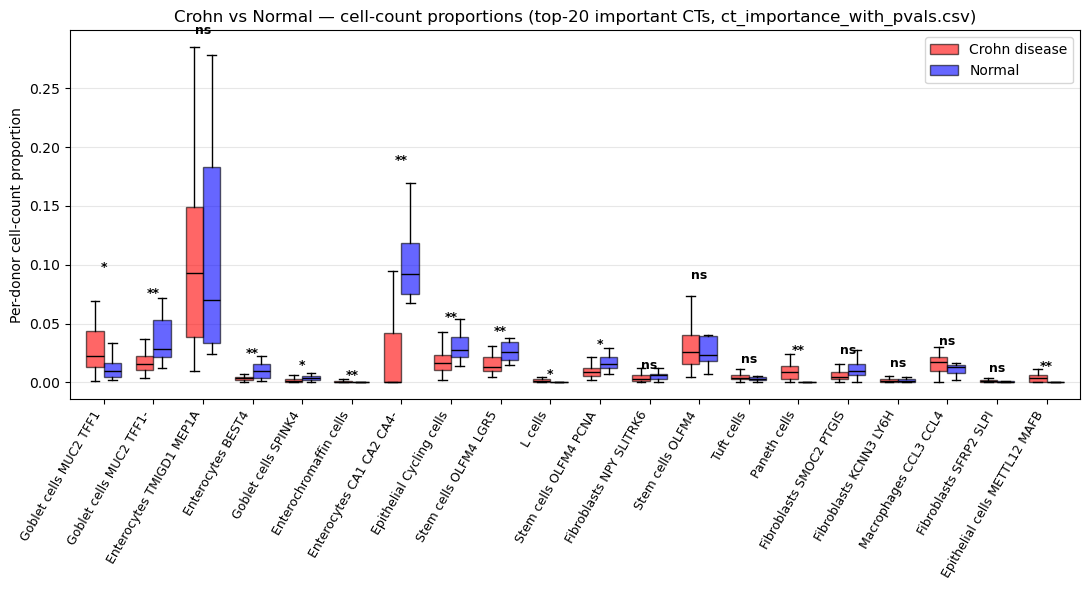

Saved plot  -> results/cta_ctimp_pvals_top20_count_proportions_boxplot.png
Saved stats -> results/cta_ctimp_pvals_top20_count_proportions_stats.csv
                    cell_type  mean_crohn  mean_normal    diff  p_value  q_value_BH  importance_score
                 Paneth cells      0.0094       0.0022  0.0072   0.0001      0.0019            0.0463
     Enterocytes CA1 CA2 CA4-      0.0325       0.0947 -0.0622   0.0007      0.0070            0.0675
       Enterochromaffin cells      0.0011       0.0002  0.0009   0.0026      0.0088            0.0739
      Goblet cells MUC2 TFF1-      0.0212       0.0363 -0.0151   0.0027      0.0088            0.0978
     Epithelial Cycling cells      0.0198       0.0301 -0.0103   0.0035      0.0088            0.0636
            Enterocytes BEST4      0.0041       0.0111 -0.0070   0.0027      0.0088            0.0781
        Stem cells OLFM4 LGR5      0.0175       0.0266 -0.0091   0.0015      0.0088            0.0593
Epithelial cells METTL12 MAFB      0

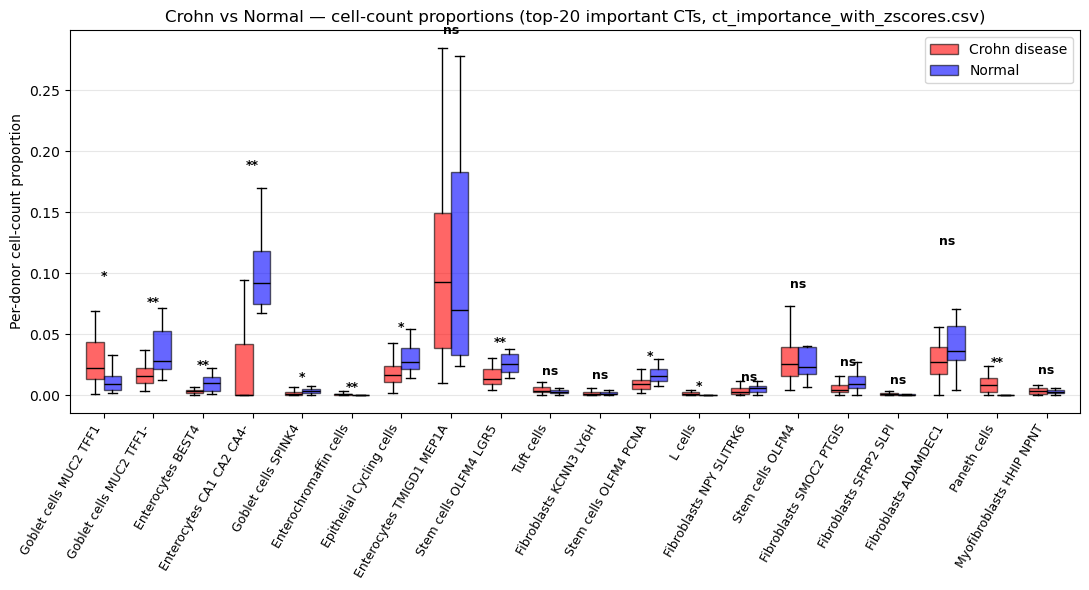

Saved plot  -> results/cta_ctimp_zscores_top20_count_proportions_boxplot.png
Saved stats -> results/cta_ctimp_zscores_top20_count_proportions_stats.csv
               cell_type  mean_crohn  mean_normal    diff  p_value  q_value_BH  importance_score
            Paneth cells      0.0094       0.0022  0.0072   0.0001      0.0019            0.0463
Enterocytes CA1 CA2 CA4-      0.0325       0.0947 -0.0622   0.0007      0.0070            0.0675
       Enterocytes BEST4      0.0041       0.0111 -0.0070   0.0027      0.0089            0.0781
 Goblet cells MUC2 TFF1-      0.0212       0.0363 -0.0151   0.0027      0.0089            0.0978
   Stem cells OLFM4 LGR5      0.0175       0.0266 -0.0091   0.0015      0.0089            0.0593
  Enterochromaffin cells      0.0011       0.0002  0.0009   0.0026      0.0089            0.0739
Epithelial Cycling cells      0.0198       0.0301 -0.0103   0.0035      0.0101            0.0636
   Stem cells OLFM4 PCNA      0.0111       0.0168 -0.0057   0.0050      

In [8]:
_ = plot_top20_proportions(
    "results/ct_importance_with_pvals.csv",
    tag="pvals",
    title_suffix="ct_importance_with_pvals.csv",
    out_prefix="cta_ctimp",
)

_ = plot_top20_proportions(
    "results/ct_importance_with_zscores.csv",
    tag="zscores",
    title_suffix="ct_importance_with_zscores.csv",
    out_prefix="cta_ctimp",
)
